In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
#https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [100]:
df = pd.read_csv("16-diabetes.csv")

In [101]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [103]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [104]:
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [105]:
for col in cols_with_zero_as_missing:
    print(col,": ",(df[col] == 0).sum())

Glucose :  5
BloodPressure :  35
SkinThickness :  227
Insulin :  374
BMI :  11


In [106]:
# 1️⃣ 0 değerleri eksik (NaN) olarak işaretle
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_as_missing] = df[cols_with_zero_as_missing].replace(0, np.nan)

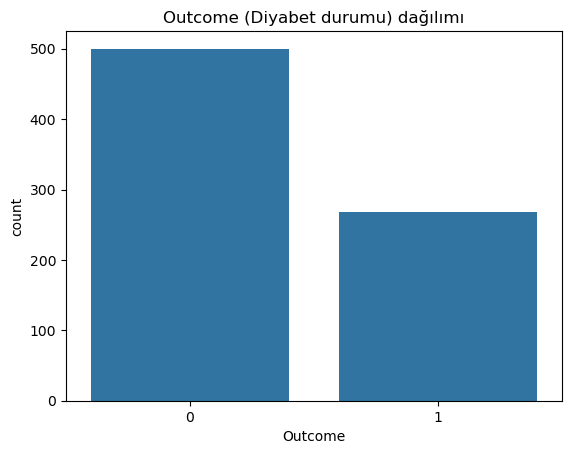

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [107]:
sns.countplot(x='Outcome', data=df)
plt.title("Outcome (Diyabet durumu) dağılımı")
plt.show()

# Oranla görmek için:
print(df['Outcome'].value_counts(normalize=True) * 100)


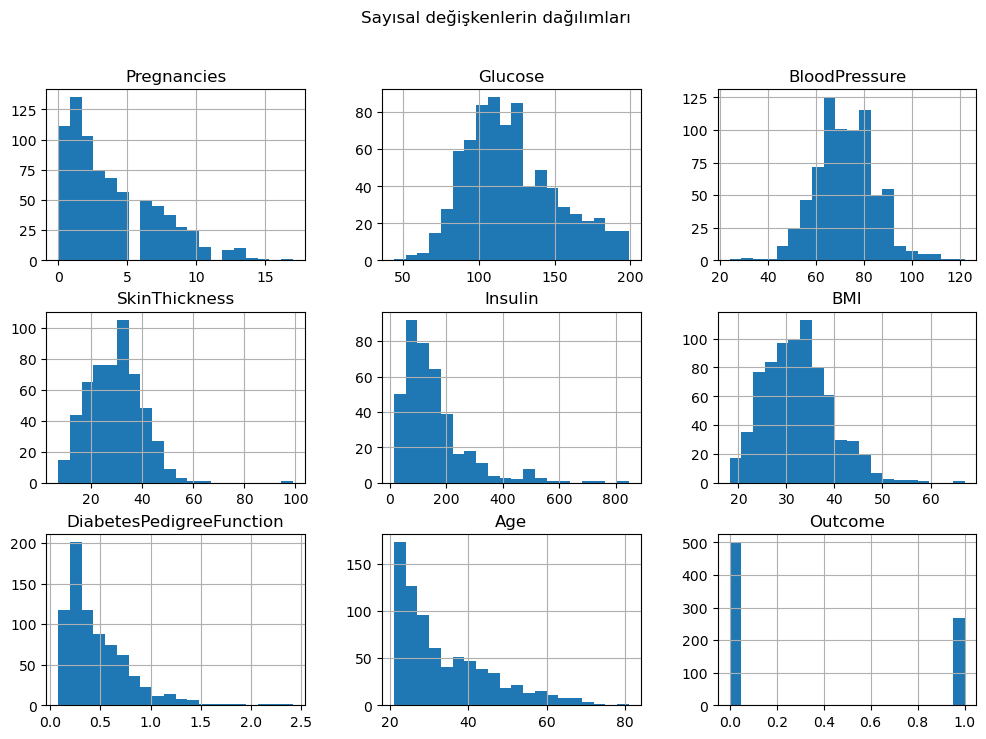

In [108]:
df.hist(bins=20, figsize=(12, 8))
plt.suptitle("Sayısal değişkenlerin dağılımları")
plt.show()

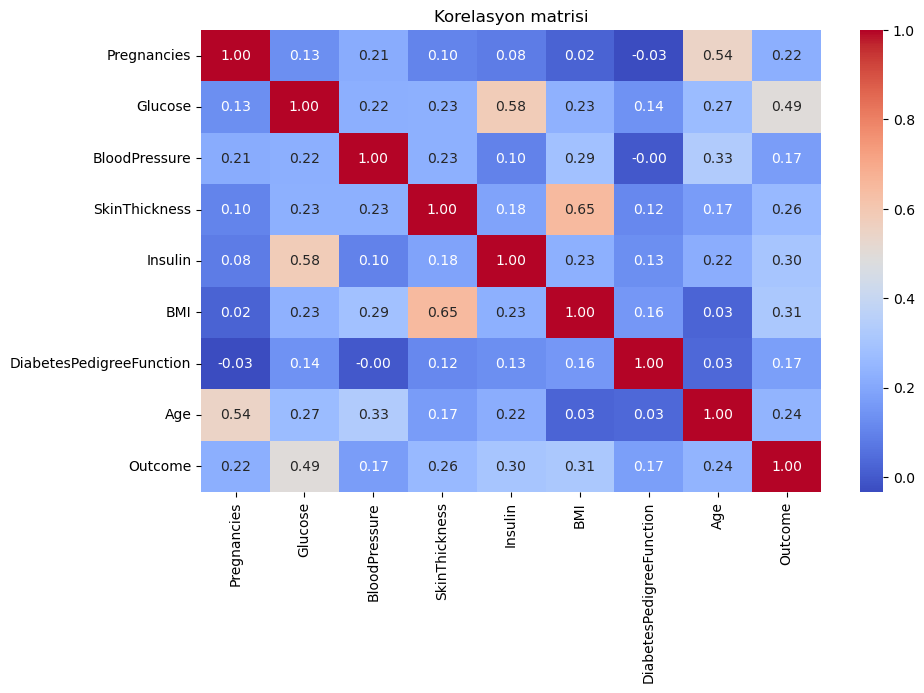

In [109]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasyon matrisi")
plt.show()

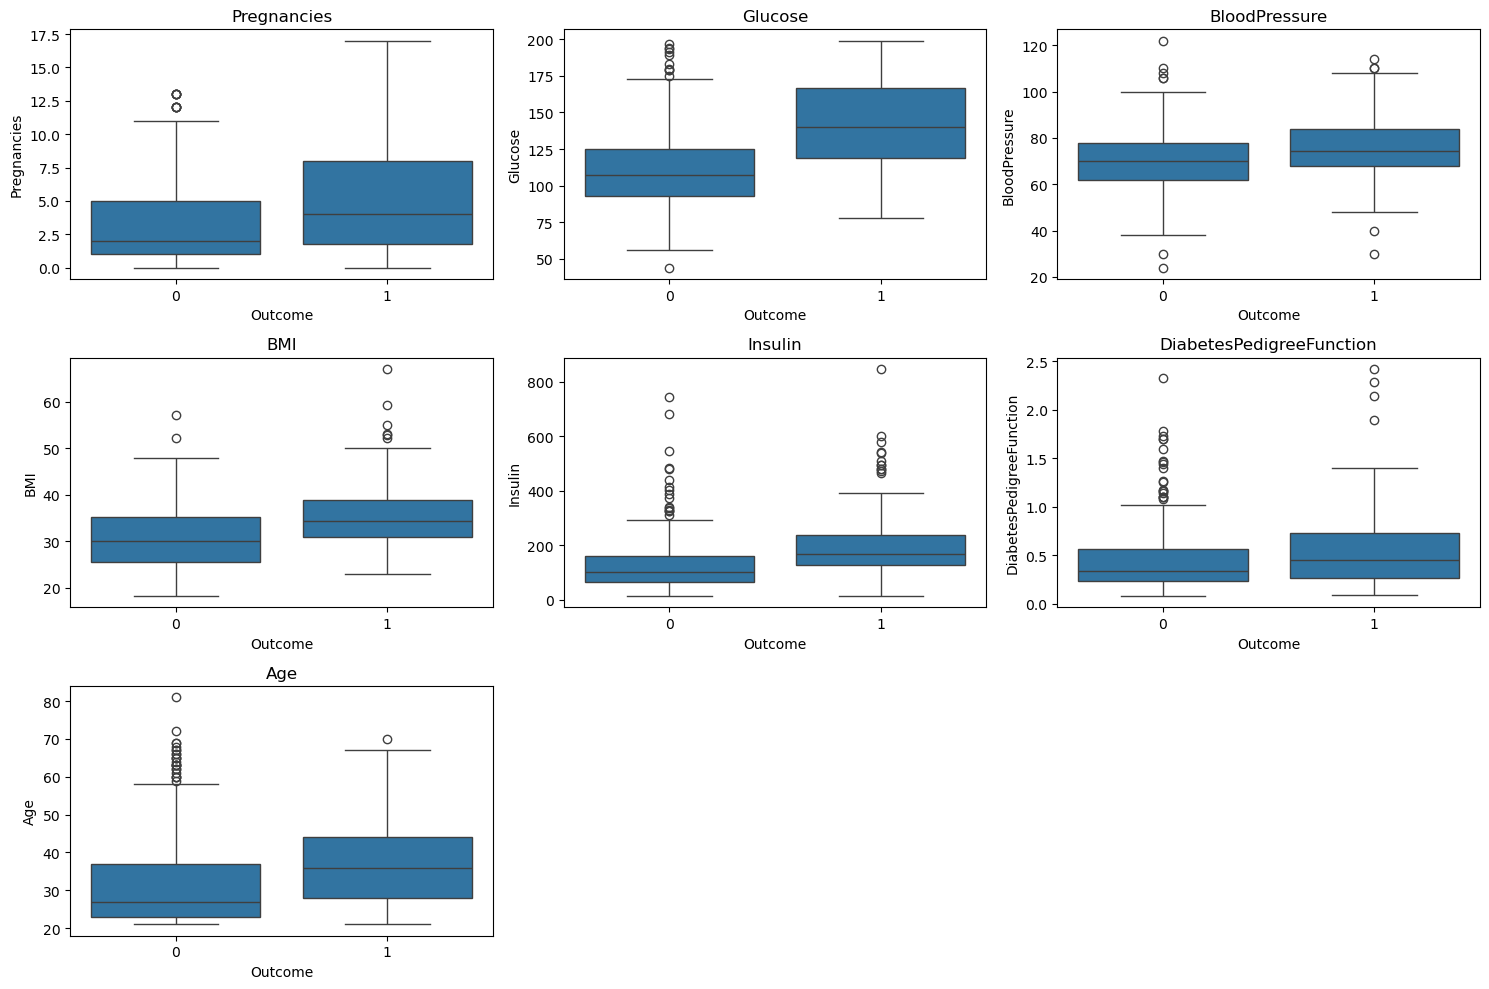

In [110]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Insulin', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

In [111]:
corr_target = df.corr()['Outcome'].sort_values(ascending=False)
display(corr_target)

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [112]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=15)

In [114]:
columns_to_fill = ["Glucose","BloodPressure","BMI","SkinThickness"]

In [115]:
# 3️⃣ Glucose, BloodPressure, SkinThickness, BMI -> medyan ile doldur
medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0, median_value)
for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [116]:
# 4️⃣ Insulin -> KNN Imputer ile doldur
imputer = KNNImputer(n_neighbors=5)

# KNN Imputer sayısal değerler üzerinde çalışır — sadece uygun kolonları seçelim
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

In [117]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()

#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [118]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier


In [119]:
# modüler hata metrikleri hesaplama fonk
def calculate_model_metrics(true, predicted):
    csf = classification_report(true, predicted)
    acc = accuracy_score(true, predicted)
    conf = confusion_matrix(true, predicted)
    
    return csf, acc, conf

In [120]:
# model tanımları
models = {
    "AdaBoost Classifier" : AdaBoostClassifier(),
    "Ridge Classifier": RidgeClassifier(random_state=42,alpha=10,solver="auto"),
}


In [121]:
# model eğitimi ve hata metrikleri çıktısı
for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    model_train_classification_report, model_train_accuracy_score, model_train_confusion_matrix = calculate_model_metrics(y_train, y_train_pred)
    model_test_classification_report, model_test_accuracy_score, model_test_confusion_matrix = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("Classification Report :", model_train_classification_report)
    print("Accuracy Score :", model_train_accuracy_score)
    print("Confusion Matrix :", model_train_confusion_matrix)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("Classification Report:", model_test_classification_report)
    print("Accuracy Score :", model_test_accuracy_score)
    print("Confusion Matrix :", model_test_confusion_matrix)

    print("-----------------------------")
    print("\n")

AdaBoostClassifier()
Evaluation for Training Set
Classification Report :               precision    recall  f1-score   support

           0       0.82      0.89      0.85       392
           1       0.77      0.66      0.71       222

    accuracy                           0.80       614
   macro avg       0.79      0.77      0.78       614
weighted avg       0.80      0.80      0.80       614

Accuracy Score : 0.8045602605863192
Confusion Matrix : [[347  45]
 [ 75 147]]
-----------------------------
Evaluation for Test Set
Classification Report:               precision    recall  f1-score   support

           0       0.84      0.82      0.83       108
           1       0.60      0.63      0.62        46

    accuracy                           0.77       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.77      0.77       154

Accuracy Score : 0.7662337662337663
Confusion Matrix : [[89 19]
 [17 29]]
-----------------------------


RidgeClassif